# T008 · Protein structure and data acquisition from PDBe 
**Note:** This talktorial is a rewrite of T008 using the PDBe API architecture rather than the RCSB PDB APIs. Talktorial is modernized by using mmCIF rather than PDB formated coordinate files and replaces legacy Ligand Expo and OpenCADD dependencies.

**Teachopencadd T008 notes:**
T008 · Protein data acquisition: Protein Data Bank (PDB) 
**Note:** This talktorial is a part of TeachOpenCADD, a platform that aims to teach domain-specific skills and to provide pipeline templates as starting points for research projects.
Authors:
- Anja Georgi, CADD seminar, 2017, Charité/FU Berlin
- Majid Vafadar, CADD seminar, 2018, Charité/FU Berlin
- Jaime Rodríguez-Guerra, [Volkamer lab, Charité](https://volkamerlab.org/)
- Dominique Sydow, [Volkamer lab, Charité](https://volkamerlab.org/)

__Talktorial T008__: This talktorial is part of the TeachOpenCADD pipeline described in the first TeachOpenCADD publication ([_J. Cheminform._ (2019), **11**, 1-7](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-019-0351-x)), comprising of talktorials T001-T010.

## Aim of this talktorial

In this talktorial, we conduct the groundwork for the next talktorial where we will generate a ligand-based ensemble pharmacophore for EGFR. Therefore, we 
(i) fetch all PDB IDs for EGFR from the PDBe database that fullfil certain criteria (e.g. ligand-bound structures with high resolution), 
(ii) retrieve protein-ligand structures with the best structural quality, 
(iii) align all structures, and 
(iv) extract and save the ligands to be used in the next talktorial.

### Contents in Practical

* Select a query protein
* Get the number of PDB entries for a query protein
* Find PDB entries fullfilling certain conditions
* Select PDB entries with the highest resolution
* Get metadata of ligands from top structures
* Draw top ligand molecules
* Create protein-ligand ID pairs
* Align PDB structures and extract ligands

## Theory

### Protein Data Bank (PDB)

The RCSB Protein Data Bank (PDB) is a comprehensive structural biology information database and a key resource in areas of structural biology, such as structural genomics and drug design ([PDB website](http://www.rcsb.org/)).

Structural data is generated from structural determination methods such as X-ray crystallography (most common method), nuclear magnetic resonance (NMR), and cryo electron microscopy (cryo-EM). 
For each entry, the database contains (i) the 3D coordinates of the atoms and the bonds connecting these atoms for proteins, ligand, cofactors, water molecules, and ions, as well as (ii) meta information on the structural data such as the PDB ID, the authors, the deposition date, the structural determination method used, and the structural resolution.
The structural resolution is a measure of the collected data quality and has the unit Å (Angstrom); the lower the value, the higher the quality of the structure. 

The PDB website offers a 3D visualization of the protein structures (with ligand interactions if available) and a structure quality metrics, as can be seen for the PDB entry of an example epidermal growth factor receptor (EGFR) with the PDB ID [3UG5](https://www.rcsb.org/structure/3UG5).

![protein ligand complex](images/protein-ligand-complex.png)

*Figure 1*: The protein structure (in gray) with an interacting ligand (in green) is shown for an example epidermal growth factor receptor (EGFR) with the PDB ID 3UG5.

### PDBe

Protein Data Bank in Europe (PDBe, https://www.ebi.ac.uk/pdbe/) provides programmatic access to the wwPDB archive through a collection of APIs and services. In this talktorial, PDBe will be used to:

- identify relevant EGFR structures,
- retrieve structure metadata,
- obtain ligand information,
- download structure files in mmCIF format.

API documentation: https://www.ebi.ac.uk/pdbe/api/v2/doc/

### mmCIF

The Macromolecular Crystallographic Information File (mmCIF) format is the current standard format used by the PDB. Compared to the legacy PDB format, mmCIF supports larger structure models (more atoms), stores more complete metadata, avoids legacy formatting limitations, and is new standard for modern structural biology workflows. In this talktorial we will use pdbecif to work with mmCIF files. 
Reference: Glen van Ginkel, Lukáš Pravda, José M. Dana, Mihaly Varadi, Peter Keller, Stephen Anyango and Sameer Velankar. PDBeCIF: an open‑source mmCIF/CIF parsing and processing package BMC Bioinformatics (2021) 22:383
Documentation: https://pdbeurope.github.io/pdbecif/

## Practical

In [195]:
# As pdbecif is not available in the environment, we will install it first
!pip install pdbecif

In [ ]:
import json
from pathlib import Path

import requests
import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pdbecif.mmcif_io import CifFileReader

import biotite.structure as struc
from biotite.structure.io.pdb import PDBFile

from rdkit import Chem
from rdkit.Chem import Draw

import nglview as nv

In [197]:
# Define paths
HERE = Path(_dh[-1])
DATA = HERE / "data"

### Select a query protein

We use EGFR as query protein for this talktorial. The UniProt ID of EGFR is `P00533`, which will be used to retrieve structures through PDBe's UniProt mapping endpoints.

In [198]:
UNIPROT_ID = "P00533"
PROTEIN_NAME = "EGFR"

### Get the number of PDB entries for a query protein 

How many structures are available in the PDB for EGFR since the PDB was established in 1971?

**Retrieve EGFR structures from PDBe**
We use the PDBe API to retrieve all PDB entries associated with the EGFR UniProt accession (`P00533`). The returned list of PDB identifiers will be used throughout the remainder of this tutorial for structure filtering, ligand retrieval and structural analysis.

In [199]:
url = (f"https://www.ebi.ac.uk/pdbe/api/mappings/best_structures/{UNIPROT_ID}")

response = requests.get(url)
response.raise_for_status()

data = response.json()

structures = data[UNIPROT_ID]

pdb_ids = sorted(
    {
        structure["pdb_id"].upper()
        for structure in structures
    }
)

today = datetime.datetime.now()

print(
    f"Number of structures on "
    f"{today.year}-{today.month}-{today.day}: "
    f"{len(pdb_ids)}"
)

# Show the first 10 PDB IDs
pdb_ids[:10]

Number of structures on 2026-9-3: 392


['1IVO',
 '1M14',
 '1M17',
 '1MOX',
 '1NQL',
 '1XKK',
 '1YY9',
 '1Z9I',
 '2EB2',
 '2EB3']

### Retrieve metadata for all EGFR structures

The structure-mapping endpoint gave us the list of PDB entries associated with EGFR. Next, we retrieve metadata for all structures in a single bulk API request. This allows us to store information such as:
- experimental method
- structure resolution
- deposition and release dates
- structure title

We will combine this information into a single master dataframe that will be used throughout the remainder of the tutorial for filtering, ranking and selecting structures.

In [200]:
print(len(pdb_ids))
print(pdb_ids[:5])

392
['1IVO', '1M14', '1M17', '1MOX', '1NQL']


In [201]:
# Retrieve metadata for all EGFR structures in one bulk request

url = "https://www.ebi.ac.uk/pdbe/api/v2/pdb/entry/summary"

response = requests.post(url,json=",".join(pdb_ids))
response.raise_for_status()

entry_metadata = response.json()
print(f"Retrieved metadata for {len(entry_metadata)} structures.")

Retrieved metadata for 392 structures.


In [202]:
# Lets inspect the metadata for the first PDB ID in the list
first_pdb_id = next(iter(entry_metadata))
print(first_pdb_id)
print(entry_metadata[first_pdb_id][0].keys())

1ivo
dict_keys(['title', 'processing_site', 'deposition_site', 'deposition_date', 'release_date', 'revision_date', 'experimental_method_class', 'experimental_method', 'split_entry', 'related_structures', 'entry_authors', 'number_of_entities', 'assemblies'])


In [203]:
# Convert PDBe response into a dataframe so we can easily use the retrieved metadata for further analysis
records = []

for pdb_id, entries in entry_metadata.items():
    if not entries:
        continue
    entry = entries[0]
    records.append({
        "pdb_id": pdb_id.upper(),
        "title": entry.get("title"),
        "deposition_date": entry.get("deposition_date"),
        "release_date": entry.get("release_date"),
        "revision_date": entry.get("revision_date"),
        "experimental_method": ", ".join(
            entry.get("experimental_method", [])
        ),
        "experimental_method_class": ", ".join(
            entry.get("experimental_method_class", [])
        ),
    })

# Create the metadata dataframe
df_metadata = pd.DataFrame(records)

# Convert dates
for column in ["deposition_date", "release_date", "revision_date"]:
    df_metadata[column] = pd.to_datetime(df_metadata[column], format="%Y%m%d", errors="coerce")

# Add convenience columns
df_metadata["deposition_year"] = (df_metadata["deposition_date"].dt.year)
df_metadata["release_year"] = (df_metadata["release_date"].dt.year)
print(f"Created metadata table with {len(df_metadata)} structures.")

df_metadata.head()

Created metadata table with 392 structures.


,pdb_id,title,deposition_date,release_date,revision_date,experimental_method,experimental_method_class,deposition_year,release_year
0,1IVO,Crystal Structure of the Complex of Human Epid...,2002-03-28,2002-10-16,2024-10-23,X-ray diffraction,x-ray,2002,2002
1,1M14,Tyrosine Kinase Domain from Epidermal Growth F...,2002-06-17,2002-09-04,2024-02-14,X-ray diffraction,x-ray,2002,2002
2,1M17,Epidermal Growth Factor Receptor tyrosine kina...,2002-06-17,2002-09-04,2024-02-14,X-ray diffraction,x-ray,2002,2002
3,1MOX,Crystal Structure of Human Epidermal Growth Fa...,2002-09-10,2003-09-10,2024-11-13,X-ray diffraction,x-ray,2002,2003
4,1NQL,Structure of the extracellular domain of human...,2003-01-21,2003-03-11,2024-12-25,X-ray diffraction,x-ray,2003,2003


### Retrieve experimental metadata
The summary endpoint provides general information about each structure. For structure-quality assessment we need to retrieve experimental metadata like experimental method, structure resolution, diffraction information and beamline information as well. So we need another API call to enrich our dataset

In [204]:
url = "https://www.ebi.ac.uk/pdbe/api/v2/pdb/entry/experiment"

response = requests.post(url, json=",".join(pdb_ids))
response.raise_for_status()

experiment_data = response.json()
print(
    f"Retrieved experimental metadata for "
    f"{len(experiment_data)} structures."
)

Retrieved experimental metadata for 392 structures.


In [205]:
# Now we add the experimental metadata to the dataframe
experiment_records = []

for pdb_id, entries in experiment_data.items():
    if not entries:
        continue
    entry = entries[0]

    experiment_records.append({
    "pdb_id": pdb_id.upper(),
    "resolution": entry.get("resolution"),
    "resolution_high": entry.get("resolution_high"),
    "resolution_low": entry.get("resolution_low"),
    "beam_source_name": (
        entry.get("diffraction_experiment", [{}])[0]
        .get("beam_source_name")
    ),
})

df_experiment = pd.DataFrame(experiment_records)
df_metadata = df_metadata.merge(
    df_experiment,
    on="pdb_id",
    how="left",
)

df_metadata.head()

,pdb_id,title,deposition_date,release_date,revision_date,experimental_method,experimental_method_class,deposition_year,release_year,resolution,resolution_high,resolution_low,beam_source_name
0,1IVO,Crystal Structure of the Complex of Human Epid...,2002-03-28,2002-10-16,2024-10-23,X-ray diffraction,x-ray,2002,2002,3.3,3.3,10.0,Synchrotron
1,1M14,Tyrosine Kinase Domain from Epidermal Growth F...,2002-06-17,2002-09-04,2024-02-14,X-ray diffraction,x-ray,2002,2002,2.6,2.6,50.0,Synchrotron
2,1M17,Epidermal Growth Factor Receptor tyrosine kina...,2002-06-17,2002-09-04,2024-02-14,X-ray diffraction,x-ray,2002,2002,2.6,2.6,30.0,Synchrotron
3,1MOX,Crystal Structure of Human Epidermal Growth Fa...,2002-09-10,2003-09-10,2024-11-13,X-ray diffraction,x-ray,2002,2003,2.5,2.5,20.0,Rotating anode
4,1NQL,Structure of the extracellular domain of human...,2003-01-21,2003-03-11,2024-12-25,X-ray diffraction,x-ray,2003,2003,2.8,2.8,20.0,Synchrotron


In [206]:
df_metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   pdb_id                     392 non-null    str           
 1   title                      392 non-null    str           
 2   deposition_date            392 non-null    datetime64[us]
 3   release_date               392 non-null    datetime64[us]
 4   revision_date              392 non-null    datetime64[us]
 5   experimental_method        392 non-null    str           
 6   experimental_method_class  392 non-null    str           
 7   deposition_year            392 non-null    int32         
 8   release_year               392 non-null    int32         
 9   resolution                 386 non-null    float64       
 10  resolution_high            368 non-null    float64       
 11  resolution_low             367 non-null    float64       
 12  beam_source_name   

### Growth of the EGFR structural landscape
The number of experimentally determined EGFR structures in the PDB has increased steadily over time. Using the release year metadata retrieved, we can visualize how many new EGFR structures became publicly available each year.
You will see that the number of available EGFR structures has steadily increased over the years. Plotting the cumulative number of released structures provides a simple overview of the growth of structural knowledge for this important drug target.

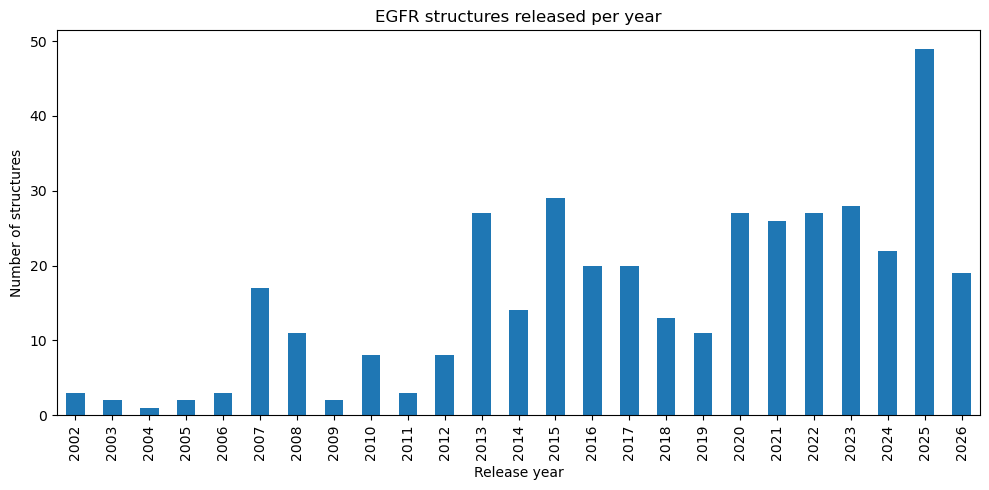

In [207]:
structures_per_year = (df_metadata["release_year"].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(10, 5))

structures_per_year.plot(kind="bar", ax=ax)

ax.set_title("EGFR structures released per year")
ax.set_xlabel("Release year")
ax.set_ylabel("Number of structures")

plt.tight_layout()
plt.show()

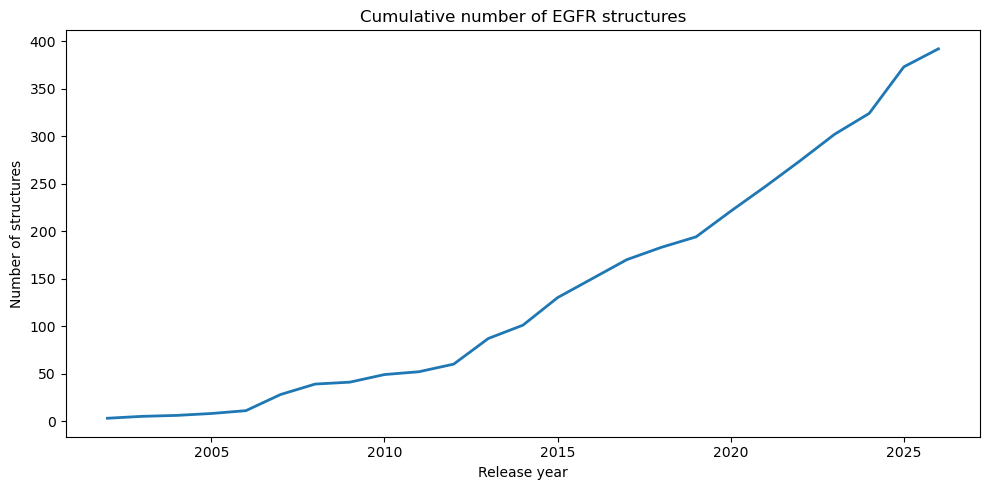

In [208]:
cumulative_structures = (df_metadata["release_year"].value_counts().sort_index().cumsum())
fig, ax = plt.subplots(figsize=(10, 5))
cumulative_structures.plot(ax=ax, linewidth=2)

ax.set_title("Cumulative number of EGFR structures")
ax.set_xlabel("Release year")
ax.set_ylabel("Number of structures")

plt.tight_layout()
plt.show()

**Discussion**
Do you observe periods of accelerated structure deposition?
What factors may have contributed to the increasing number of available EGFR structures over time?

### Find PDB entries fulfilling certain conditions
Not all available structures are equally useful for structure-based drug design. To identify high-quality protein–ligand structures, we apply several filtering criteria:
- X-ray structures only
- Resolution better than 3.0 Å (keep in mind: For X-ray crystallography structures, lower resolution values indicate higher structural detail.)
- Structures deposited before 2020

We then rank the filtered EGFR structures by resolution and inspect the best available structures.

In [209]:
# Define our best and worst structure model based on resolution
best_structure = df_metadata.loc[df_metadata["resolution"].idxmin()]
worst_structure = df_metadata.loc[df_metadata["resolution"].idxmax()]   
print(f"Best structure: {best_structure['pdb_id']} with resolution {best_structure['resolution']} Å")
print(f"Worst structure: {worst_structure['pdb_id']} with resolution {worst_structure['resolution']} Å")

Best structure: 8A27 with resolution 1.07 Å
Worst structure: 7OM4 with resolution 6.05 Å


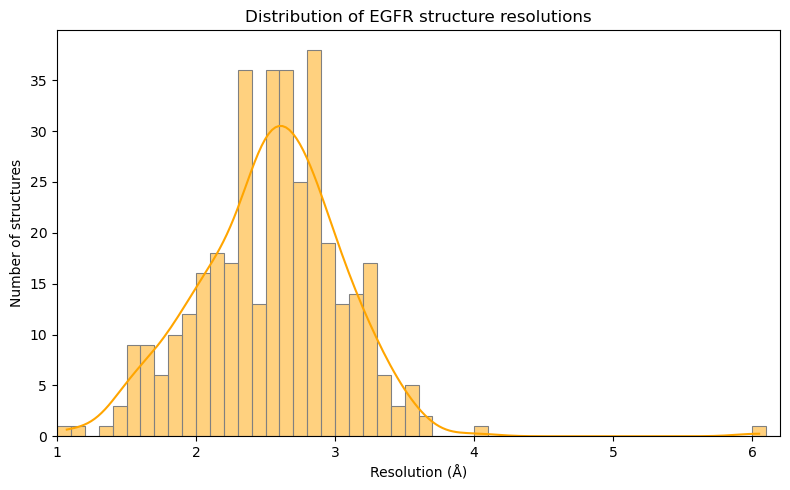

In [210]:
# Lets now have a look at the distribution of resolution of all EGFR structure models we obtained
resolutions = df_metadata.loc[df_metadata["experimental_method_class"] == "x-ray","resolution"].dropna()

plt.figure(figsize=(8, 5))

# We can set the x-axis range based on the best and worst resolution we found above
sns.histplot(resolutions, binwidth=0.1, binrange=(1, 6.2),
             kde=True, color="orange", edgecolor="grey")

plt.title("Distribution of EGFR structure resolutions")
plt.xlabel("Resolution (Å)")
plt.xlim(1, 6.2)
plt.ylabel("Number of structures")

plt.tight_layout()
plt.show()

In [211]:
# Here we filter for high-quality X-ray EGFR structures released before 2020
filtered_structures = df_metadata[
    (df_metadata["experimental_method_class"] == "x-ray")
    & (df_metadata["resolution"] <= 3.0)
    & (df_metadata["release_date"] < "2020-01-01")
].copy()

print(f"{len(filtered_structures)} structures pass the quality filters.")
filtered_structures.head()

153 structures pass the quality filters.


,pdb_id,title,deposition_date,release_date,revision_date,experimental_method,experimental_method_class,deposition_year,release_year,resolution,resolution_high,resolution_low,beam_source_name
1,1M14,Tyrosine Kinase Domain from Epidermal Growth F...,2002-06-17,2002-09-04,2024-02-14,X-ray diffraction,x-ray,2002,2002,2.6,2.6,50.00,Synchrotron
2,1M17,Epidermal Growth Factor Receptor tyrosine kina...,2002-06-17,2002-09-04,2024-02-14,X-ray diffraction,x-ray,2002,2002,2.6,2.6,30.00,Synchrotron
3,1MOX,Crystal Structure of Human Epidermal Growth Fa...,2002-09-10,2003-09-10,2024-11-13,X-ray diffraction,x-ray,2002,2003,2.5,2.5,20.00,Rotating anode
4,1NQL,Structure of the extracellular domain of human...,2003-01-21,2003-03-11,2024-12-25,X-ray diffraction,x-ray,2003,2003,2.8,2.8,20.00,Synchrotron
5,1XKK,EGFR kinase domain complexed with a quinazolin...,2004-09-29,2004-12-07,2023-08-23,X-ray diffraction,x-ray,2004,2004,2.4,2.4,35.44,Synchrotron


In [212]:
# Find the top 10 structures with the best resolution
top_structures = (filtered_structures.sort_values("resolution").reset_index(drop=True))
top_structures[["pdb_id", "resolution", "release_date", "title"]].head(10)

,pdb_id,resolution,release_date,title
0,5UG9,1.33,2017-03-22,Crystal structure of the EGFR kinase domain (L...
1,5HG8,1.42,2016-02-03,"EGFR (L858R, T790M, V948R) in complex with N-[..."
2,5UG8,1.46,2017-03-22,Crystal structure of the EGFR kinase domain (L...
3,3POZ,1.50,2011-03-30,EGFR Kinase domain complexed with tak-285
4,5HG5,1.52,2016-02-03,"EGFR (L858R, T790M, V948R) in complex with N-{..."
5,3VRP,1.52,2013-03-06,Crystal structure of the tyrosine kinase bindi...
6,5CNO,1.55,2015-07-29,Crystal structure of the EGFR kinase domain mu...
7,5UGC,1.58,2017-03-22,Crystal structure of the EGFR kinase domain (L...
8,3G5Y,1.59,2010-02-09,Antibodies Specifically Targeting a Locally Mi...
9,5U8L,1.60,2017-01-25,Crystal structure of EGFR kinase domain in com...


### Retrieve molecule information
To further characterize the candidate structure models for analyses, we need to retrieve molecular composition information from PDBe, including polymer chains and non-polymer entities (ligands). As we already filtered for experimental method and resolution, we will only retrieve this data for our top10 structure models.
This information allows us to:
- identify protein chains,
- identify co-crystallized ligands,
- determine ligand molecular weights,
- select suitable protein-ligand complexes for further analysis.

If a structure contains several ligands, we select the largest ligand. Note: this is a simple, but not comprehensive method to select a ligand in the binding site of a protein. This approach may also select a cofactor bound to the protein. Therefore, please check the automatically selected top ligands visually before further usage.

In [213]:
top_pdb_ids = top_structures["pdb_id"].head(10).tolist()
url = "https://www.ebi.ac.uk/pdbe/api/v2/pdb/entry/molecules"

response = requests.post(url, json=",".join(top_pdb_ids))
response.raise_for_status()

molecule_data = response.json()

print(f"Retrieved molecule data for {len(molecule_data)} structures.")

Retrieved molecule data for 10 structures.


In [214]:
# Now we will extract the ligand information from the molecule data we retrieved from PDBe. 
# We will create a list of dictionaries containing the relevant ligand information for each structure
# and transform it into a pandas dataframe that we can easily use for further analysis

ligand_records = []

for pdb_id, molecules in molecule_data.items():
    for molecule in molecules:
        if molecule.get("molecule_type") != "bound":
            continue

        ligand_records.append({
            "pdb_id": pdb_id.upper(),
            "ligand_id": (
                molecule.get("chem_comp_ids", [None])[0]
            ),
            "ligand_name": (
                molecule.get("molecule_name", [None])[0]
            ),
            "ligand_weight": molecule.get("weight"),
            "n_copies": molecule.get("number_of_copies"),
        })

df_ligands = pd.DataFrame(ligand_records)
df_ligands.sort_values(["pdb_id", "ligand_weight"],ascending=[True, False])


,pdb_id,ligand_id,ligand_name,ligand_weight,n_copies
1,3POZ,03P,N-{2-[4-({3-chloro-4-[3-(trifluoromethyl)pheno...,547.957,1
0,3POZ,SO4,SULFATE ION,96.063,3
24,3VRP,CA,CALCIUM ION,40.078,1
2,5CNO,ANP,PHOSPHOAMINOPHOSPHONIC ACID-ADENYLATE ESTER,506.196,2
3,5CNO,MG,MAGNESIUM ION,24.305,2
4,5HG5,633,N-{3-[(2-{[4-(4-methylpiperazin-1-yl)phenyl]am...,471.554,1
5,5HG5,SO4,SULFATE ION,96.063,1
6,5HG5,GOL,GLYCEROL,92.094,1
7,5HG8,634,N-[3-({2-[(1-methyl-1H-pyrazol-4-yl)amino]-7H-...,377.400,1
8,5HG8,SO4,SULFATE ION,96.063,2


Many structures contain crystallization additives, buffer components or ions. To focus on biologically relevant protein-ligand complexes, we retain only the largest bound molecule for each structure and remove small non-drug-like compounds.

In [215]:
df_ligands = df_ligands[df_ligands["ligand_weight"] >= 100].copy().reset_index(drop=True)
df_ligands

,pdb_id,ligand_id,ligand_name,ligand_weight,n_copies
0,3POZ,03P,N-{2-[4-({3-chloro-4-[3-(trifluoromethyl)pheno...,547.957,1
1,5CNO,ANP,PHOSPHOAMINOPHOSPHONIC ACID-ADENYLATE ESTER,506.196,2
2,5HG5,633,N-{3-[(2-{[4-(4-methylpiperazin-1-yl)phenyl]am...,471.554,1
3,5HG8,634,N-[3-({2-[(1-methyl-1H-pyrazol-4-yl)amino]-7H-...,377.400,1
4,5U8L,O44,4-[(4-{4-[(3-cyclopropyl-1H-pyrazol-5-yl)amino...,538.597,1
5,5UG8,8BP,"N-[(3R,4R)-4-fluoro-1-{6-[(1-methyl-1H-pyrazol...",415.468,1
6,5UG9,8AM,"N-[(3R,4R)-4-fluoro-1-{6-[(3-methoxy-1-methyl-...",445.494,1
7,5UGC,8BS,"N-[(3R,4R)-4-fluoro-1-{6-[(3-methoxy-1-methyl-...",417.441,1


In [216]:
# For structures with multiple ligands, we will keep only the largest (heaviest) ligand for each structure
largest_ligands = (df_ligands.loc[df_ligands.groupby("pdb_id")["ligand_weight"].idxmax()].reset_index(drop=True).drop(columns=["n_copies"]))    
largest_ligands

,pdb_id,ligand_id,ligand_name,ligand_weight
0,3POZ,03P,N-{2-[4-({3-chloro-4-[3-(trifluoromethyl)pheno...,547.957
1,5CNO,ANP,PHOSPHOAMINOPHOSPHONIC ACID-ADENYLATE ESTER,506.196
2,5HG5,633,N-{3-[(2-{[4-(4-methylpiperazin-1-yl)phenyl]am...,471.554
3,5HG8,634,N-[3-({2-[(1-methyl-1H-pyrazol-4-yl)amino]-7H-...,377.400
4,5U8L,O44,4-[(4-{4-[(3-cyclopropyl-1H-pyrazol-5-yl)amino...,538.597
5,5UG8,8BP,"N-[(3R,4R)-4-fluoro-1-{6-[(1-methyl-1H-pyrazol...",415.468
6,5UG9,8AM,"N-[(3R,4R)-4-fluoro-1-{6-[(3-methoxy-1-methyl-...",445.494
7,5UGC,8BS,"N-[(3R,4R)-4-fluoro-1-{6-[(3-methoxy-1-methyl-...",417.441


The molecule endpoint provided the ligand identifiers present in each protein–ligand complex and we selected the ligands we are interested in. Next, we wiil retrieve detailed chemical information for these ligands, including molecular descriptors and chemical structure information that can be used for visualization and downstream analyses.

In [217]:
# Unique ligand identifiers
ligand_ids = sorted(largest_ligands["ligand_id"].unique())

# Retrieve ligand metadata in a single bulk request
url = "https://www.ebi.ac.uk/pdbe/api/v2/pdb/compound/summary"

response = requests.post(url,json=",".join(ligand_ids))
response.raise_for_status()

compound_data = response.json()
print(f"Retrieved metadata for {len(compound_data)} ligands.")

Retrieved metadata for 8 ligands.


In [218]:
# Now we build a ligand metadata table
compound_records = []

for ligand_id, entries in compound_data.items():
    if not entries:
        continue
    compound = entries[0]

    # Extract first available SMILES
    smiles = None
    if compound.get("smiles"):
        smiles = compound["smiles"][0].get("name")

    compound_records.append({
        "ligand_id": ligand_id,
        "name": compound.get("name"),
        "formula": compound.get("formula"),
        "weight": compound.get("weight"),
        "formal_charge": compound.get("formal_charge"),
        "compound_type": compound.get("compound_type"),
        "inchi": compound.get("inchi"),
        "inchi_key": compound.get("inchi_key"),
        "smiles": smiles,
    })

df_compounds = pd.DataFrame(compound_records)
df_compounds

,ligand_id,name,formula,weight,formal_charge,compound_type,inchi,inchi_key,smiles
0,8AM,"N-[(3R,4R)-4-fluoro-1-{6-[(3-methoxy-1-methyl-...",C20 H28 F N9 O2,445.494,0,NON-POLYMER,InChI=1S/C20H28FN9O2/c1-6-15(31)23-13-9-29(7-1...,MJLFLAORJNTNDV-CHWSQXEVSA-N,CCC(=O)N[C@@H]1CN(C[C@H]1F)c2nc(c3c(n2)n(cn3)C...
1,633,N-{3-[(2-{[4-(4-methylpiperazin-1-yl)phenyl]am...,C26 H29 N7 O2,471.554,0,NON-POLYMER,InChI=1S/C26H29N7O2/c1-3-23(34)28-19-5-4-6-21(...,JZXKYJJXGSXWTQ-UHFFFAOYSA-N,CCC(=O)Nc1cccc(c1)Oc2c3cc[nH]c3nc(n2)Nc4ccc(cc...
2,ANP,PHOSPHOAMINOPHOSPHONIC ACID-ADENYLATE ESTER,C10 H17 N6 O12 P3,506.196,0,NON-POLYMER,InChI=1S/C10H17N6O12P3/c11-8-5-9(13-2-12-8)16(...,PVKSNHVPLWYQGJ-KQYNXXCUSA-N,c1nc(c2c(n1)n(cn2)[C@H]3[C@@H]([C@@H]([C@H](O3...
3,03P,N-{2-[4-({3-chloro-4-[3-(trifluoromethyl)pheno...,C26 H25 Cl F3 N5 O3,547.957,0,NON-POLYMER,"InChI=1S/C26H25ClF3N5O3/c1-25(2,37)14-22(36)31...",ZYQXEVJIFYIBHZ-UHFFFAOYSA-N,CC(C)(CC(=O)NCCn1ccc2c1c(ncn2)Nc3ccc(c(c3)Cl)O...
4,8BP,"N-[(3R,4R)-4-fluoro-1-{6-[(1-methyl-1H-pyrazol...",C19 H26 F N9 O,415.468,0,NON-POLYMER,InChI=1S/C19H26FN9O/c1-5-15(30)24-14-9-28(8-13...,CGULPICMFDDQRH-ZIAGYGMSSA-N,CCC(=O)N[C@@H]1CN(C[C@H]1F)c2nc(c3c(n2)n(cn3)C...
5,O44,4-[(4-{4-[(3-cyclopropyl-1H-pyrazol-5-yl)amino...,C25 H27 F N8 O3 S,538.597,0,NON-POLYMER,InChI=1S/C25H27FN8O3S/c1-2-9-27-24(35)21-15-22...,ZBSPMOBILDLOCV-UHFFFAOYSA-N,C#CCNC(=O)c1cc(nc(n1)N2CCN(CC2)Cc3ccc(cc3)S(=O...
6,8BS,"N-[(3R,4R)-4-fluoro-1-{6-[(3-methoxy-1-methyl-...",C18 H24 F N9 O2,417.441,0,NON-POLYMER,InChI=1S/C18H24FN9O2/c1-5-13(29)21-11-8-28(6-1...,XWNKXCUQRQRAFF-GHMZBOCLSA-N,CCC(=O)N[C@@H]1CN(C[C@H]1F)c2nc(c3c(n2)n(cn3)C...
7,634,N-[3-({2-[(1-methyl-1H-pyrazol-4-yl)amino]-7H-...,C19 H19 N7 O2,377.400,0,NON-POLYMER,InChI=1S/C19H19N7O2/c1-3-16(27)22-12-5-4-6-14(...,YWNHZBNRKJYHTR-UHFFFAOYSA-N,CCC(=O)Nc1cccc(c1)Oc2c3cc[nH]c3nc(n2)Nc4cnn(c4)C


In [219]:
# Then merge it back into your selected ligands table to enrich the ligand information with the metadata we retrieved and store it in a CSV file for later use
largest_ligands = largest_ligands.merge(df_compounds,on="ligand_id",how="left")
largest_ligands.to_csv(DATA / "top_ligands_data_T008.csv", header=True, index=False)
largest_ligands

,pdb_id,ligand_id,ligand_name,ligand_weight,name,formula,weight,formal_charge,compound_type,inchi,inchi_key,smiles
0,3POZ,03P,N-{2-[4-({3-chloro-4-[3-(trifluoromethyl)pheno...,547.957,N-{2-[4-({3-chloro-4-[3-(trifluoromethyl)pheno...,C26 H25 Cl F3 N5 O3,547.957,0,NON-POLYMER,"InChI=1S/C26H25ClF3N5O3/c1-25(2,37)14-22(36)31...",ZYQXEVJIFYIBHZ-UHFFFAOYSA-N,CC(C)(CC(=O)NCCn1ccc2c1c(ncn2)Nc3ccc(c(c3)Cl)O...
1,5CNO,ANP,PHOSPHOAMINOPHOSPHONIC ACID-ADENYLATE ESTER,506.196,PHOSPHOAMINOPHOSPHONIC ACID-ADENYLATE ESTER,C10 H17 N6 O12 P3,506.196,0,NON-POLYMER,InChI=1S/C10H17N6O12P3/c11-8-5-9(13-2-12-8)16(...,PVKSNHVPLWYQGJ-KQYNXXCUSA-N,c1nc(c2c(n1)n(cn2)[C@H]3[C@@H]([C@@H]([C@H](O3...
2,5HG5,633,N-{3-[(2-{[4-(4-methylpiperazin-1-yl)phenyl]am...,471.554,N-{3-[(2-{[4-(4-methylpiperazin-1-yl)phenyl]am...,C26 H29 N7 O2,471.554,0,NON-POLYMER,InChI=1S/C26H29N7O2/c1-3-23(34)28-19-5-4-6-21(...,JZXKYJJXGSXWTQ-UHFFFAOYSA-N,CCC(=O)Nc1cccc(c1)Oc2c3cc[nH]c3nc(n2)Nc4ccc(cc...
3,5HG8,634,N-[3-({2-[(1-methyl-1H-pyrazol-4-yl)amino]-7H-...,377.400,N-[3-({2-[(1-methyl-1H-pyrazol-4-yl)amino]-7H-...,C19 H19 N7 O2,377.400,0,NON-POLYMER,InChI=1S/C19H19N7O2/c1-3-16(27)22-12-5-4-6-14(...,YWNHZBNRKJYHTR-UHFFFAOYSA-N,CCC(=O)Nc1cccc(c1)Oc2c3cc[nH]c3nc(n2)Nc4cnn(c4)C
4,5U8L,O44,4-[(4-{4-[(3-cyclopropyl-1H-pyrazol-5-yl)amino...,538.597,4-[(4-{4-[(3-cyclopropyl-1H-pyrazol-5-yl)amino...,C25 H27 F N8 O3 S,538.597,0,NON-POLYMER,InChI=1S/C25H27FN8O3S/c1-2-9-27-24(35)21-15-22...,ZBSPMOBILDLOCV-UHFFFAOYSA-N,C#CCNC(=O)c1cc(nc(n1)N2CCN(CC2)Cc3ccc(cc3)S(=O...
5,5UG8,8BP,"N-[(3R,4R)-4-fluoro-1-{6-[(1-methyl-1H-pyrazol...",415.468,"N-[(3R,4R)-4-fluoro-1-{6-[(1-methyl-1H-pyrazol...",C19 H26 F N9 O,415.468,0,NON-POLYMER,InChI=1S/C19H26FN9O/c1-5-15(30)24-14-9-28(8-13...,CGULPICMFDDQRH-ZIAGYGMSSA-N,CCC(=O)N[C@@H]1CN(C[C@H]1F)c2nc(c3c(n2)n(cn3)C...
6,5UG9,8AM,"N-[(3R,4R)-4-fluoro-1-{6-[(3-methoxy-1-methyl-...",445.494,"N-[(3R,4R)-4-fluoro-1-{6-[(3-methoxy-1-methyl-...",C20 H28 F N9 O2,445.494,0,NON-POLYMER,InChI=1S/C20H28FN9O2/c1-6-15(31)23-13-9-29(7-1...,MJLFLAORJNTNDV-CHWSQXEVSA-N,CCC(=O)N[C@@H]1CN(C[C@H]1F)c2nc(c3c(n2)n(cn3)C...
7,5UGC,8BS,"N-[(3R,4R)-4-fluoro-1-{6-[(3-methoxy-1-methyl-...",417.441,"N-[(3R,4R)-4-fluoro-1-{6-[(3-methoxy-1-methyl-...",C18 H24 F N9 O2,417.441,0,NON-POLYMER,InChI=1S/C18H24FN9O2/c1-5-13(29)21-11-8-28(6-1...,XWNKXCUQRQRAFF-GHMZBOCLSA-N,CCC(=O)N[C@@H]1CN(C[C@H]1F)c2nc(c3c(n2)n(cn3)C...


### Draw top ligand molecules

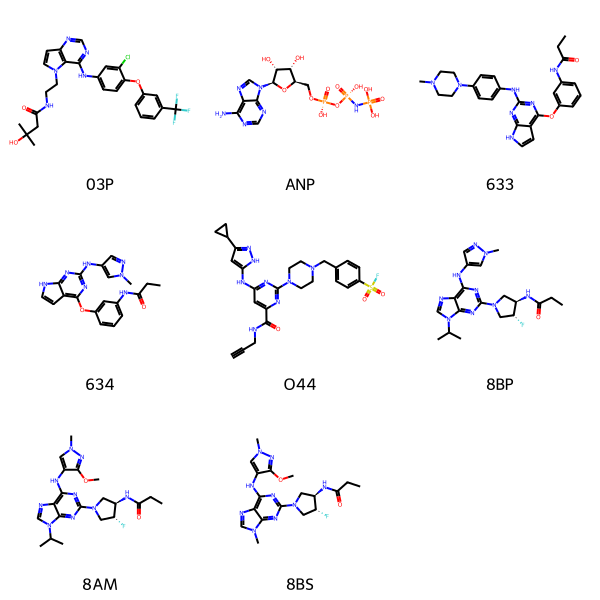

In [220]:
# Let's visualize the ligands we retrieved for the top EGFR structures
Draw.MolsToGridImage(
    mols=[Chem.MolFromSmiles(smiles) for smiles in largest_ligands["smiles"]],
    legends=list(largest_ligands["ligand_id"]))

### Align PDB structures and extract ligands
In the next talktorial (T009) we want to build ligand-based ensemble pharmacophores in the next talktorial, it is necessary to align all structures to each other in 3D. To prepare these structures for alignment and ligand extraction, we download the corresponding coordinates in mmCIF format.

In [221]:
# We first store the protein-ligand pairs in a dictionary for later use
protein_ligand_pairs = dict(zip(largest_ligands["pdb_id"],largest_ligands["ligand_id"]))
protein_ligand_pairs

{'3POZ': '03P',
 '5CNO': 'ANP',
 '5HG5': '633',
 '5HG8': '634',
 '5U8L': 'O44',
 '5UG8': '8BP',
 '5UG9': '8AM',
 '5UGC': '8BS'}

In [222]:
# Setting up the path for storing the downloaded mmCIF files
STRUCTURE_DIR = DATA / "structures"
STRUCTURE_DIR.mkdir(exist_ok=True)
# Calling RCSB PDB API to download the mmCIF files and store them in the structures directory we created above 
# TODO:API will change soon!!! as we ran out of 4 character PDB IDs and will be moving to 7 character PDB IDs
for pdb_id in protein_ligand_pairs:
    url = (f"https://files.rcsb.org/download/"f"{pdb_id}.cif")
    destination = STRUCTURE_DIR / f"{pdb_id}.cif"

    response = requests.get(url)
    response.raise_for_status()
    destination.write_bytes(response.content)

print(f"Downloaded {len(protein_ligand_pairs)} mmCIF files.")

Downloaded 8 mmCIF files.


#### Intermezzo: Exploring an mmCIF file
mmCIF stores both atomic coordinates and extensive metadata in a structured tabular format.An mmCIF file consists of multiple categories, each describing a specific aspect of the structure. Two relevant categories for structure-based drug discovery are the `_atom_site` and `_chem_comp` category.

The `_atom_site` category
The atomic coordinates of the structure are stored in the `_atom_site` category. Each row corresponds to one atom and contains information such as:
- atom name
- residue name
- chain identifier
- Cartesian coordinates

Most structural biology libraries ultimately extract coordinate information from this category.

The `_chem_comp` category
The `_chem_comp` category describes the chemical components present in a structure. For each component, it provides information such as:
- component identifier (e.g. ATP, 8AM, NAG)
- chemical name
- molecular formula
- molecular weight
- component type

This category is particularly important for structure-based drug design because it allows us to identify and characterize co-crystallized ligands directly from the structure file.

Now let's read one of the downloaded mmCIF files to inspect its contents. We will use the `pdbecif` library to read the mmCIF file and extract its data into a Python dictionary for further analysis.

In [223]:
reader = CifFileReader()
cif_data = reader.read(str(STRUCTURE_DIR / "5UG9.cif"))
# Print the keys of the cif_data dictionary
cif_data.keys()

dict_keys(['5UG9'])

In [224]:
# Display the number of mmCIF categories and the first 20 keys of the structure data for the file we just read in
structure = cif_data["5UG9"]
print(f"Number of mmCIF categories: {len(structure.keys())}")
list(structure.keys())[:20]

Number of mmCIF categories: 72


['_entry',
 '_audit_conform',
 '_database_2',
 '_pdbx_audit_revision_history',
 '_pdbx_audit_revision_details',
 '_pdbx_audit_revision_group',
 '_pdbx_audit_revision_category',
 '_pdbx_audit_revision_item',
 '_pdbx_database_status',
 '_pdbx_database_related',
 '_audit_author',
 '_citation',
 '_citation_author',
 '_entity',
 '_entity_name_com',
 '_entity_poly',
 '_pdbx_entity_nonpoly',
 '_entity_poly_seq',
 '_entity_src_gen',
 '_chem_comp']

In [225]:
# Which data categories are available in the "_chem_comp" category of the mmCIF file?
structure["_chem_comp"].keys()

dict_keys(['id', 'type', 'mon_nstd_flag', 'name', 'pdbx_synonyms', 'formula', 'formula_weight'])

In [226]:
# Which data categories are available in the "_atom_site" category of the mmCIF file?
atom_site = structure["_atom_site"]
atom_site.keys()

dict_keys(['group_PDB', 'id', 'type_symbol', 'label_atom_id', 'label_alt_id', 'label_comp_id', 'label_asym_id', 'label_entity_id', 'label_seq_id', 'pdbx_PDB_ins_code', 'Cartn_x', 'Cartn_y', 'Cartn_z', 'occupancy', 'B_iso_or_equiv', 'pdbx_formal_charge', 'auth_seq_id', 'auth_comp_id', 'auth_asym_id', 'auth_atom_id', 'pdbx_PDB_model_num'])

In [227]:
# We can convert the "_atom_site" category data into a pandas dataframe for more human friendly inspection and analysis
atom_df = pd.DataFrame(atom_site)
atom_df.head()

,group_PDB,id,type_symbol,label_atom_id,label_alt_id,label_comp_id,label_asym_id,label_entity_id,label_seq_id,pdbx_PDB_ins_code,...,Cartn_y,Cartn_z,occupancy,B_iso_or_equiv,pdbx_formal_charge,auth_seq_id,auth_comp_id,auth_asym_id,auth_atom_id,pdbx_PDB_model_num
0,ATOM,1,N,N,.,ALA,A,1,9,?,...,11.254,-39.148,1.00,44.42,?,702,ALA,A,N,1
1,ATOM,2,C,CA,.,ALA,A,1,9,?,...,11.883,-39.231,1.00,44.40,?,702,ALA,A,CA,1
2,ATOM,3,C,C,.,ALA,A,1,9,?,...,13.072,-40.185,1.00,44.38,?,702,ALA,A,C,1
3,ATOM,4,O,O,.,ALA,A,1,9,?,...,13.998,-40.024,1.00,44.63,?,702,ALA,A,O,1
4,ATOM,5,C,CB,.,ALA,A,1,9,?,...,12.333,-37.844,1.00,43.72,?,702,ALA,A,CB,1


### Create Biotite structure objects

We have explored the contents of a single mmCIF file and identified how atomic coordinates are stored in the `_atom_site` category. To prepare all selected structures for alignment and ligand extraction, we now convert each mmCIF file into a Biotite `AtomArray` and separate the ligand from the protein (or to be precise non-ligand) atoms. 

Some structures contain multiple protein chains, either because of crystallographic symmetry, biological oligomerization or co-crystallized proteins. To ensure a consistent structural comparison, we retain only the chain corresponding to the target protein before performing the alignment.

In [228]:
def cif_to_atom_array(cif_file):
    '''Helperfunction to convert an mmCIF file into a Biotite AtomArray.'''
    reader = CifFileReader()
    cif_data = reader.read(str(cif_file))

    structure_id = next(iter(cif_data))
    atom_df = pd.DataFrame(cif_data[structure_id]["_atom_site"])
    # Keep only primary atom locations
    atom_df = atom_df[atom_df["label_alt_id"].isin([".", "A"])].copy()

    atom_array = struc.AtomArray(len(atom_df))

    # Store atomic coordinates (x, y, z)
    atom_array.coord = (atom_df[["Cartn_x", "Cartn_y", "Cartn_z"]].astype(float).to_numpy())

    # Store residue numbering
    atom_array.res_id = (atom_df["label_seq_id"].replace(".", pd.NA).fillna(-1).astype(int).to_numpy())

    # Store additional atomic properties
    atom_array.atom_name = atom_df["label_atom_id"].to_numpy(dtype="U4")
    atom_array.res_name = atom_df["label_comp_id"].to_numpy(dtype="U3")
    atom_array.chain_id = atom_df["label_asym_id"].to_numpy(dtype="U4")
    atom_array.element = atom_df["type_symbol"].to_numpy(dtype="U2")

    return atom_array

In [229]:
# Convert all downloaded mmCIF files into Biotite AtomArrays
structures = {pdb_id: cif_to_atom_array(STRUCTURE_DIR / f"{pdb_id}.cif")for pdb_id in protein_ligand_pairs}
print(f"Created {len(structures)} Biotite structures.")

Created 8 Biotite structures.


Structures may contain multiple copies of the target protein or additional protein chains. To ensure a consistent structural comparison, we identify the molecular entity corresponding to the target UniProt accession and retain a single representative chain from that entity. In the current case some structures contain multiple copies of the EGFR kinase domain. For structural comparison, a single representative copy is sufficient. Therefore, we retain one EGFR chain from each structure before performing the alignment. 

In [230]:
# Select the most complete chain of the target protein
target_chains = {}

for pdb_id in structures:
    structure = structures[pdb_id]
    molecules = molecule_data[pdb_id.lower()]

    # Identify the target protein entity
    target_entity = max((molecule for molecule in molecules if molecule.get("molecule_type") == "polypeptide(L)"),
                        key=lambda molecule: molecule.get("length", 0))

    chain_sizes = {}
    for chain in target_entity["in_chains"]:
        chain_sizes[chain] = structure[structure.chain_id == chain].array_length()    
        target_chains[pdb_id] = max(chain_sizes, key=chain_sizes.get)

In [231]:
# Inspect selected chains and their sizes
for pdb_id, selected_chain in target_chains.items():
    chain_size = structures[pdb_id][structures[pdb_id].chain_id == selected_chain].array_length()
    print(f"{pdb_id}: Selected entity {selected_chain} containing {chain_size} atoms")

3POZ: Selected entity A containing 2357 atoms
5CNO: Selected entity B containing 2435 atoms
5HG5: Selected entity A containing 2431 atoms
5HG8: Selected entity A containing 2418 atoms
5U8L: Selected entity A containing 2325 atoms
5UG8: Selected entity A containing 2254 atoms
5UG9: Selected entity A containing 2254 atoms
5UGC: Selected entity A containing 2254 atoms


In [232]:
# Create protein-only structures for alignment
protein_structures = {}
for pdb_id, structure in structures.items():
    selected_chain = target_chains[pdb_id]
    protein_structures[pdb_id] = structure[structure.chain_id == selected_chain]

Now we split a structure into protein and ligand atoms

In [233]:
def extract_protein_and_ligand(structure, ligand_id):
    '''Helper function to split a structure into protein and ligand atoms'''
    # Select all atoms belonging to the ligand
    ligand_mask = structure.res_name == ligand_id

    # Select all remaining atoms
    protein_mask = ~ligand_mask

    protein = structure[protein_mask]
    ligand = structure[ligand_mask]

    return protein, ligand

In [234]:
# Separate protein and ligand atoms for all structures
complexes = {}

for pdb_id in structures:
    protein = protein_structures[pdb_id]
    ligand_id = protein_ligand_pairs[pdb_id]
    ligand = structures[pdb_id][structures[pdb_id].res_name == ligand_id]

    complexes[pdb_id] = {"protein": protein,"ligand": ligand}


In [235]:
# Inspect the number of protein and ligand atoms as a sanity check to ensure that the protein and ligand atoms were correctly separated
for pdb_id, complex_ in complexes.items():
    print(f"{pdb_id}: {complex_['protein'].array_length()} protein atoms, {complex_['ligand'].array_length()} ligand atoms")

3POZ: 2357 protein atoms, 38 ligand atoms
5CNO: 2435 protein atoms, 62 ligand atoms
5HG5: 2431 protein atoms, 35 ligand atoms
5HG8: 2418 protein atoms, 28 ligand atoms
5U8L: 2325 protein atoms, 35 ligand atoms
5UG8: 2254 protein atoms, 30 ligand atoms
5UG9: 2254 protein atoms, 32 ligand atoms
5UGC: 2254 protein atoms, 30 ligand atoms


### Prepare protein atoms for structural alignment

The goal of the next step is to align the EGFR structure models s in three-dimensional space. To avoid introducing noise from ligands, solvent molecules and crystallization additives, we perform the alignment using protein atoms only. Since all selected structure models represent the EGFR kinase domain, we can use the protein backbone atoms as a common structural reference for alignment.

In [236]:
# Backbone atoms used for structural alignment
BACKBONE_ATOMS = ["N", "CA", "C", "O"]

# Little helper function to select backbone atoms from a protein structure
def select_backbone_atoms(structure):
    backbone_atoms = ["N", "CA", "C", "O"]
    return structure[pd.Series(structure.atom_name).isin(backbone_atoms)]


Structural alignment requires a reference structure to which all other structures will be aligned. We use the highest-resolution EGFR structure as the reference. 

In [237]:
# Select the highest-resolution structure as alignment reference
reference_pdb_id = (largest_ligands.merge(filtered_structures[["pdb_id", "resolution"]],on="pdb_id").sort_values("resolution").iloc[0]["pdb_id"])

# Store the reference protein and backbone atoms
reference_protein = complexes[reference_pdb_id]["protein"]
reference_backbone = select_backbone_atoms(reference_protein)
print(f"Reference structure: {reference_pdb_id}")

Reference structure: 5UG9


In [238]:
test_pdb_id = next(
    pdb_id
    for pdb_id in complexes
    if pdb_id != reference_pdb_id
)

test_backbone = select_backbone_atoms(
    complexes[test_pdb_id]["protein"]
)

print(test_pdb_id)
print(reference_backbone.array_length())
print(test_backbone.array_length())

3POZ
1120
1172


Different structures may contain missing residues, unresolved loops or slightly different construct boundaries. To ensure a meaningful structural superposition, we identify backbone atoms that are present in both structures and retain only these common atoms for the alignment procedure.

In [239]:
# Create sets of equivalent residue-atom pairs
reference_pairs = set(zip(reference_backbone.res_id, reference_backbone.atom_name))

test_pairs = set(zip(test_backbone.res_id,test_backbone.atom_name,))

# Keep only atom pairs present in both structures
common_pairs = reference_pairs & test_pairs

# Remove non-polymer placeholder residues
common_pairs = {pair for pair in common_pairs if pair[0] != -1}

print(f"{len(common_pairs)} equivalent backbone atoms found.")

1064 equivalent backbone atoms found.


In [240]:
# Select matching backbone atoms from the reference structure
reference_mask = [(res_id, atom_name) in common_pairs for res_id, atom_name in zip(reference_backbone.res_id,reference_backbone.atom_name)]
reference_matched = reference_backbone[reference_mask]

# Select matching backbone atoms from the comparison structure
test_mask = [(res_id, atom_name) in common_pairs
    for res_id, atom_name in zip(
        test_backbone.res_id,
        test_backbone.atom_name)]

test_matched = test_backbone[test_mask]

In [241]:
# Verify that both structures contain the same number of matched atoms
print(reference_matched.array_length(),test_matched.array_length())

1064 1064


Now we can align the structure models in 3D

In [242]:
# Calculate the optimal superposition
fitted_atoms, transformation = struc.superimpose(reference_matched,test_matched,)
print(f"Aligned {test_pdb_id} to {reference_pdb_id}")

# Calculate the RMSD after alignment
rmsd = struc.rmsd(reference_matched,fitted_atoms)
print(f"Alignment RMSD: {rmsd:.2f} Å")

Aligned 3POZ to 5UG9
Alignment RMSD: 6.12 Å


In [243]:
# Apply the alignment transformation to the full structure
aligned_structure = transformation.apply(complexes[test_pdb_id]["protein"])

Let's have a look at the two aligned structure models

In [275]:
# Save the reference structure
reference_pdb_path = DATA / f"{reference_pdb_id}_reference.pdb"

pdb_file = PDBFile()
pdb_file.set_structure(reference_protein)
pdb_file.write(reference_pdb_path)

# Save the aligned structure
aligned_pdb_path = DATA / f"{test_pdb_id}_aligned.pdb"
pdb_file = PDBFile()
pdb_file.set_structure(aligned_structure)
pdb_file.write(aligned_pdb_path)

# Visualize the alignment
view = nv.NGLWidget()
view.add_component(str(reference_pdb_path))
view.add_component(str(aligned_pdb_path))
view.clear_representations()

view[0].add_cartoon()
view[1].add_cartoon()
view

NGLWidget()

Having successfully aligned one structure to the reference, we can now apply the same procedure to the remaining protein structures. The resulting transformations will later be applied to the corresponding ligands, allowing us to compare all ligands in a common reference frame.

In [244]:
# Helper function to align a structure against the reference structure
def align_to_reference(reference_protein, mobile_protein):
    reference_backbone = select_backbone_atoms(reference_protein)
    mobile_backbone = select_backbone_atoms(mobile_protein)

    # Create sets of equivalent residue-atom pairs
    reference_pairs = set(zip(reference_backbone.res_id, reference_backbone.atom_name))

    mobile_pairs = set(zip(mobile_backbone.res_id,mobile_backbone.atom_name))

    # Identify common backbone atoms
    common_pairs = reference_pairs & mobile_pairs
    common_pairs = { pair for pair in common_pairs if pair[0] != -1}

    # Select matching atoms from the reference structure
    reference_mask = [(res_id, atom_name) in common_pairs
        for res_id, atom_name in zip(
            reference_backbone.res_id,
            reference_backbone.atom_name)]

    # Select matching atoms from the mobile structure
    mobile_mask = [(res_id, atom_name) in common_pairs
        for res_id, atom_name in zip(
            mobile_backbone.res_id,
            mobile_backbone.atom_name)]

    reference_matched = reference_backbone[reference_mask]
    mobile_matched = mobile_backbone[mobile_mask]

    # Verify matching atom counts
    print(f"Reference atoms: {reference_matched.array_length()}")
    print(f"Mobile atoms: {mobile_matched.array_length()}")

    # Calculate superposition
    fitted_atoms, transformation = struc.superimpose(reference_matched,mobile_matched)

    # Calculate alignment quality
    rmsd = struc.rmsd(reference_matched, fitted_atoms)
    return transformation, rmsd

In [245]:
# Store aligned complexes and RMSD values
aligned_complexes = {}
alignment_summary = []

# for pdb_id, complex_ in complexes.items():
for pdb_id, complex_ in complexes.items():

    if pdb_id == reference_pdb_id:
        continue

    print(f"Aligning {pdb_id}")

    transformation, rmsd = align_to_reference(
        reference_protein,
        complex_["protein"],
    )
    if pdb_id == reference_pdb_id:
        aligned_complexes[pdb_id] = {"protein": complex_["protein"], "ligand": complex_["ligand"]}
        alignment_summary.append({"pdb_id": pdb_id, "rmsd": 0.0})
        continue

    transformation, rmsd = align_to_reference(reference_protein,complex_["protein"])

    # Apply alignment transformation
    aligned_protein = transformation.apply(complex_["protein"])
    aligned_ligand = transformation.apply(complex_["ligand"])
    aligned_complexes[pdb_id] = {"protein": aligned_protein,"ligand": aligned_ligand}
    alignment_summary.append({"pdb_id": pdb_id,"rmsd": rmsd,})

Aligning 3POZ
Reference atoms: 1064
Mobile atoms: 1064
Reference atoms: 1064
Mobile atoms: 1064
Aligning 5CNO
Reference atoms: 1064
Mobile atoms: 1064
Reference atoms: 1064
Mobile atoms: 1064
Aligning 5HG5
Reference atoms: 1120
Mobile atoms: 1120
Reference atoms: 1120
Mobile atoms: 1120
Aligning 5HG8
Reference atoms: 1120
Mobile atoms: 1120
Reference atoms: 1120
Mobile atoms: 1120
Aligning 5U8L
Reference atoms: 1120
Mobile atoms: 1120
Reference atoms: 1120
Mobile atoms: 1120
Aligning 5UG8
Reference atoms: 1120
Mobile atoms: 1120
Reference atoms: 1120
Mobile atoms: 1120
Aligning 5UGC
Reference atoms: 1120
Mobile atoms: 1120
Reference atoms: 1120
Mobile atoms: 1120


In [246]:
# Summarise alignment RMSDs
df_alignment = (pd.DataFrame(alignment_summary).sort_values("rmsd"))
df_alignment

,pdb_id,rmsd
5,5UG8,0.109257
6,5UGC,0.160319
2,5HG5,0.584098
3,5HG8,0.614128
4,5U8L,0.711674
1,5CNO,4.179477
0,3POZ,6.116626


In [247]:
# Display alignment statistics
df_alignment.describe()

,rmsd
count,7.000000
mean,1.782226
std,2.377298
min,0.109257
25%,0.372209
50%,0.614128
75%,2.445575
max,6.116626


> **TODO: Visualize the structural alignment**
>
> A 3D visualization of the aligned structures would make it easier to assess the quality of the superposition and understand the calculated RMSD values.
>
> Potential implementation:
>
> - Export aligned structures to a format compatible with NGLView.
> - Display the reference structure together with one or more aligned structures.
> - Use distinct colors to highlight the degree of structural overlap.
>
> This visualization is not required for the remainder of the workflow and can be implemented later.

In [270]:
# Include the reference structure
aligned_proteins = {
    reference_pdb_id: reference_protein,
    **{
        pdb_id: complex_["protein"]
        for pdb_id, complex_ in aligned_complexes.items()
    },
}

view = nv.NGLWidget()

for pdb_id, protein in aligned_proteins.items():

    pdb_file = PDBFile()
    pdb_file.set_structure(protein)

    pdb_path = DATA / f"{pdb_id}_aligned.pdb"
    pdb_file.write(pdb_path)

    view.add_component(str(pdb_path))

view

NGLWidget()

The protein structures have now been aligned to a common reference frame. Because the alignment transformation was also applied to the corresponding ligands, the ligand coordinates are now directly comparable between structures. We therefore extract the aligned ligands for visualization and subsequent pharmacophore generation.

In [249]:
# Collect aligned ligands
aligned_ligands = { pdb_id: complex_["ligand"] for pdb_id, complex_ in aligned_complexes.items()}
print(f"Extracted {len(aligned_ligands)} aligned ligands.")

# Add the reference ligand
aligned_ligands[reference_pdb_id] = (complexes[reference_pdb_id]["ligand"])
print(f"Total aligned ligands + reference ligand: {len(aligned_ligands)}")

Extracted 7 aligned ligands.
Total aligned ligands + reference ligand: 8


In [250]:
# Inspect aligned ligand sizes
for pdb_id, ligand in aligned_ligands.items():
    print(f"{pdb_id}: {ligand.array_length()} atoms")

3POZ: 38 atoms
5CNO: 62 atoms
5HG5: 35 atoms
5HG8: 28 atoms
5U8L: 35 atoms
5UG8: 30 atoms
5UGC: 30 atoms
5UG9: 32 atoms


The alignment transformations have been applied to the ligand coordinates. Before proceeding, we perform a simple geometric sanity check by comparing the ligand centroids. Ligands that bind to the same binding site should occupy approximately the same region of space after alignment.

In [251]:
# Calculate ligand centroids
ligand_centroids = []
for pdb_id, ligand in aligned_ligands.items():
    centroid = ligand.coord.mean(axis=0)
    ligand_centroids.append({"pdb_id": pdb_id,"x": centroid[0],"y": centroid[1],"z": centroid[2]})

df_centroids = pd.DataFrame(ligand_centroids)

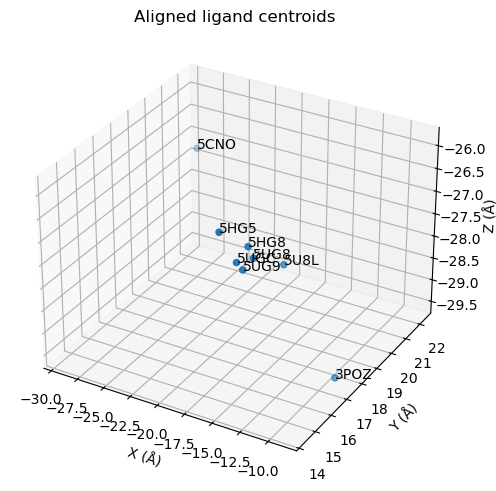

In [ ]:
# Visualize ligand centroid positions in a simple 3D plot
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(projection="3d")

ax.scatter(df_centroids["x"],df_centroids["y"],df_centroids["z"])
for _, row in df_centroids.iterrows():
    ax.text(row["x"],row["y"],row["z"],row["pdb_id"])

ax.set_xlabel("X (Å)")
ax.set_ylabel("Y (Å)")
ax.set_zlabel("Z (Å)")
ax.set_title("Aligned ligand centroids")

plt.tight_layout()
plt.show()

In [ ]:
# And in actual 3D structures
ligands_to_view = {reference_pdb_id: complexes[reference_pdb_id]["ligand"], **aligned_ligands}
view = nv.NGLWidget()

for pdb_id, ligand in ligands_to_view.items():
    pdb_file = PDBFile()
    pdb_file.set_structure(ligand)
    pdb_path = DATA / f"{pdb_id}_aligned_ligand.pdb"
    pdb_file.write(pdb_path)
    view.add_component(str(pdb_path))

view.clear_representations()
for i in range(view.n_components):
    view[i].add_ball_and_stick()
view

NGLWidget()

In [253]:
# Calculate pairwise distances between ligand centroids
from scipy.spatial.distance import pdist, squareform

distance_matrix = pd.DataFrame(squareform(pdist(df_centroids[["x", "y", "z"]])),
                               index=df_centroids["pdb_id"],columns=df_centroids["pdb_id"])
distance_matrix.round(2)

pdb_id,3POZ,5CNO,5HG5,5HG8,5U8L,5UG8,5UGC,5UG9
pdb_id,,,,,,,,
3POZ,0.00,20.96,7.72,6.28,5.37,5.82,6.49,6.10
5CNO,20.96,0.00,16.16,16.63,16.03,16.99,16.82,17.01
5HG5,7.72,16.16,0.00,1.53,3.62,1.93,1.24,1.63
5HG8,6.28,16.63,1.53,0.00,2.31,0.47,0.64,0.61
5U8L,5.37,16.03,3.62,2.31,0.00,2.19,2.84,2.61
5UG8,5.82,16.99,1.93,0.47,2.19,0.00,0.82,0.54
5UGC,6.49,16.82,1.24,0.64,2.84,0.82,0.00,0.39
5UG9,6.10,17.01,1.63,0.61,2.61,0.54,0.39,0.00


The centroid distance matrix reveals a clear clustering pattern. Most ligands occupy a highly similar region of space after alignment, with centroid distances typically below 3 Å. This indicates that these ligands are likely describing a common binding mode within the EGFR binding site. In contrast, structures 3POZ and 5CNO remain substantially displaced from the main ligand cluster, showing centroid distances of approximately 5-8 Å and 16-21 Å, respectively. These structures were also associated with the highest protein alignment RMSD values observed during the structural superposition step.

The observed differences may reflect alternative protein conformations, alternative ligand binding modes, or limitations arising from the structural diversity of the selected experimental structures. To generate a coherent ligand ensemble for downstream pharmacophore modelling, we therefore focus on the dominant ligand cluster and exclude 3POZ and 5CNO from further analyses.

In [ ]:
# Final ligand ensemble used in T009 
final_ligands = largest_ligands[~largest_ligands["pdb_id"].isin(["3POZ", "5CNO"])].copy()
final_ligands.to_csv(DATA / "final_ligands.csv", index=False)
final_ligands 

## Discussion

In this talktorial, we learned how to retrieve structural and ligand information from the Protein Data Bank using the PDBe APIs. We identified EGFR structures, collected metadata, filtered structures based on quality criteria, and selected representative protein-ligand complexes.

Using the modern mmCIF format together with the `pdbecif` and `Biotite` packages, we explored the contents of a structure file, extracted atomic coordinates, identified ligands, and aligned protein structures in three-dimensional space.

The resulting ligand ensemble was evaluated by inspecting protein alignment quality and ligand spatial overlap. Structures showing substantially different conformations or binding modes were excluded, yielding a consistent set of aligned ligands suitable for downstream pharmacophore modelling.

Although structure resolution is an important quality criterion, it should not be used in isolation. Additional considerations include ligand diversity, biological relevance, ligand potency and the presence of alternative binding modes. These factors can strongly influence the quality of subsequent pharmacophore models.

## Quiz

1. What types of information can be obtained from the Protein Data Bank and how are they represented in an mmCIF file?
2. Why is structure resolution commonly used as a quality criterion when selecting structures for structure-based drug design?
3. Why was protein structural alignment necessary before comparing the ligand binding modes?
4. Why were the structures 3POZ and 5CNO removed from the final ligand ensemble?
